# Longitudinal trajectories — symmetry/plasticity project

Tests whether cross-sectional findings extend longitudinally. Four measures, mirroring cross-sectional analyses:

1. **Peak distance** to control centroid (2D, x×y; Grill-Spector & Weiner 2014)
2. **Sum-selectivity** (log10 sum_selec_norm)
3. **Distinctiveness** (Liu Fisher-z; lower = more distinct)
4. **TFCE follow-up** — persistence (A) + preference shifts (B), within the 4 cross-sectional TFCE survivor clusters

Measures 1–3 read from `peak_coords_mni.csv` directly. Measure 4 reads two CSVs from `longitudinal_tfce_trajectories.py`.

**Longitudinal sample (OTC, ≥2 sessions):** sub-004, sub-008, sub-010, sub-021 (TC), sub-079. Sub-108 ses-02 pending MNI registration.

**TC pre/post handling:** ses-01 (pre) vs ses-03 (stable post). ses-02 (~8mo post, flagged unreliable) skipped per PI.

**Caveats to keep in mind:**
- Other 5 patients are post→post only (different question: stability/maturation, not pre/post reorganization)
- TC pre-surgical RH already atypical (Liu 2025): not a clean baseline
- n=1 for TC pre/post → directional shifts, not group inference; Crawford-Howell against control distribution

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir, git_dir

# ── Paths ──────────────────────────────────────────────────────────────
PEAK_CSV       = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'
SUB_INFO_CSV   = Path(git_dir) / 'sub_info.csv'
TFCE_LONG_DIR  = Path(processed_dir) / 'group_results' / 'longitudinal' / 'tfce'
FIG_DIR        = Path(git_dir) / 'C_results' / 'figures' / 'longitudinal'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────
PRIMARY_PARCELS = ['face_FFA', 'house_PPA', 'object_LOC', 'word_VWFA']
PARCEL_LABEL    = {'face_FFA':'FFA', 'house_PPA':'PPA', 'object_LOC':'LOC', 'word_VWFA':'VWFA'}
WTA_THRESH      = 2.326
N_PERM          = 10_000
RNG_SEED        = 42

# Longitudinal OTC patients (will be filtered against actual peak_coords below)
LONG_OTC_TARGET = ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079', 'sub-108']

# TC-specific session handling
TC_SUB     = 'sub-021'
TC_PRE_SES = 1   # pre-surgical
TC_POST_SES = 3  # stable post (skip ses-02)

# Plot styling
GROUP_COLORS = {'control': '#888888', 'OTC': '#d62728', 'TC_pre': '#1f77b4', 'TC_post': '#d62728'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

In [2]:
# ── Load + dedupe peak_coords ──────────────────────────────────────────
peak = pd.read_csv(PEAK_CSV)
# Each (sub, ses, category, hemi) has multiple rows (one per pair). For
# distance/sum-sel/distinctiveness we want one row per (sub, ses, category, hemi).
peak_u = peak.drop_duplicates(subset=['subject_id', 'session', 'category', 'hemi']).copy()

info = pd.read_csv(SUB_INFO_CSV)
info['session']    = info['ses'].str.replace('ses-', '').astype(int)
info['subject_id'] = info['sub']

# ── Longitudinal subject sets actually present in peak_coords ───────────
ses_counts  = peak_u.groupby('subject_id')['session'].nunique()
long_otc    = sorted([s for s in LONG_OTC_TARGET
                      if s in ses_counts.index and ses_counts[s] >= 2])
long_ctrl   = sorted([s for s, n in ses_counts.items()
                      if peak_u[peak_u['subject_id']==s]['group'].iloc[0] == 'control' and n >= 2])

# Controls reference (first session per control, for cross-sectional comparison)
first_ses = peak_u[peak_u['group']=='control'].groupby('subject_id')['session'].min()
ctrl_xs   = peak_u.merge(first_ses.rename('fs'), on='subject_id')
ctrl_xs   = ctrl_xs[(ctrl_xs['group']=='control') & (ctrl_xs['session']==ctrl_xs['fs'])]

print(f'Longitudinal OTC patients (≥2 ses in peak_coords): {long_otc}')
print(f'  Missing from target: {sorted(set(LONG_OTC_TARGET) - set(long_otc))}')
print(f'Longitudinal controls (≥2 ses): n={len(long_ctrl)}')
print(f'Cross-sectional control reference (first session): n={ctrl_xs["subject_id"].nunique()}')

# Check TC ses-01 presence
tc_sessions = sorted(peak_u[peak_u['subject_id']==TC_SUB]['session'].unique().tolist())
print(f'\nTC ({TC_SUB}) sessions in peak_coords: {tc_sessions}')
if TC_PRE_SES not in tc_sessions:
    warnings.warn(f'TC ses-{TC_PRE_SES:02d} NOT in peak_coords — pre/post analyses will skip. '
                  'Re-run liu_recreation_csv_v2.py with empty PRE_SURGERY_SESSIONS dict.')

Longitudinal OTC patients (≥2 ses in peak_coords): ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079', 'sub-108']
  Missing from target: []
Longitudinal controls (≥2 ses): n=8
Cross-sectional control reference (first session): n=38

TC (sub-021) sessions in peak_coords: [1, 2, 3]


In [3]:
# ── Helpers ───────────────────────────────────────────────────────────
def crawford_t(score, ctrl_values):
    """Crawford & Howell (1998) modified t-test for single case vs control sample.
    Returns (t, df, p_two_tailed, z_equivalent).
    """
    ctrl = np.asarray(ctrl_values, dtype=float)
    ctrl = ctrl[~np.isnan(ctrl)]
    n  = len(ctrl)
    m  = ctrl.mean()
    sd = ctrl.std(ddof=1)
    if sd == 0 or n < 3:
        return np.nan, n-1, np.nan, np.nan
    t  = (score - m) / (sd * np.sqrt((n + 1) / n))
    df = n - 1
    p  = 2 * (1 - stats.t.cdf(np.abs(t), df))
    z  = (score - m) / sd
    return t, df, p, z


def control_ref_band(ctrl_vals):
    """Return (mean, sd, lo, hi) for control reference band (mean ± 2 SD)."""
    v = np.asarray(ctrl_vals, dtype=float)
    v = v[~np.isnan(v)]
    if len(v) < 3:
        return np.nan, np.nan, np.nan, np.nan
    m, sd = v.mean(), v.std(ddof=1)
    return m, sd, m - 2*sd, m + 2*sd


def patient_intact_hemi(sub):
    """Return 'l' or 'r' for the intact hemisphere of an OTC patient."""
    row = info[info['subject_id'] == sub].iloc[0]
    return 'l' if row['intact_hemi'] == 'left' else 'r'

## Measure 1: Peak distance to control centroid (2D)

For each (parcel × hemi), compute control centroid as mean (peak_x_mni, peak_y_mni) across control first sessions. Per (subject × session), Euclidean distance from each peak to that centroid. Z dropped per Grill-Spector & Weiner 2014 — primarily anatomical noise in VOTC.

**Hypothesis:** patient peaks farther from control centroid post-resection; trajectories show drift or stability over time.

In [4]:
# ── Compute control centroids (parcel × hemi) ──────────────────────────
centroids = {}
for parcel in PRIMARY_PARCELS:
    for hemi in ('l', 'r'):
        rows = ctrl_xs[(ctrl_xs['category']==parcel) & (ctrl_xs['hemi']==hemi)]
        if len(rows) >= 3:
            cx, cy = rows['peak_x_mni'].mean(), rows['peak_y_mni'].mean()
            centroids[(parcel, hemi)] = (cx, cy, rows['peak_x_mni'].values, rows['peak_y_mni'].values)

def peak_distance_2d(row, centroid):
    cx, cy, _, _ = centroid
    if pd.isna(row['peak_x_mni']) or pd.isna(row['peak_y_mni']):
        return np.nan
    return float(np.sqrt((row['peak_x_mni'] - cx)**2 + (row['peak_y_mni'] - cy)**2))

# ── Build long-form distance df ────────────────────────────────────────
dist_rows = []
for _, r in peak_u.iterrows():
    key = (r['category'], r['hemi'])
    if key not in centroids:
        continue
    d = peak_distance_2d(r, centroids[key])
    if not np.isnan(d):
        dist_rows.append({
            'subject_id': r['subject_id'], 'session': r['session'],
            'group': r['group'], 'intact_hemi': r.get('intact_hemi', ''),
            'parcel': r['category'], 'hemi': r['hemi'], 'distance': d,
        })
dist_df = pd.DataFrame(dist_rows)
print(f'Distance rows: {len(dist_df):,}')

Distance rows: 584


In [5]:
# ── TC pre/post: Crawford-Howell per parcel (intact RH only) ───────────
if TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('TC pre/post — Peak distance to control centroid (intact RH)')
    print('=' * 72)
    print(f'{"Parcel":<12} {"Pre dist":>10} {"Post dist":>10} {"Δ":>8} '
          f'{"Ctrl M":>8} {"p_pre":>8} {"p_post":>8}')
    print('-' * 72)
    for parcel in PRIMARY_PARCELS:
        tc = dist_df[(dist_df['subject_id']==TC_SUB) & (dist_df['parcel']==parcel) & (dist_df['hemi']=='r')]
        pre  = tc[tc['session']==TC_PRE_SES]['distance']
        post = tc[tc['session']==TC_POST_SES]['distance']
        if pre.empty or post.empty:
            continue
        ctrl_d = dist_df[(dist_df['group']=='control') & (dist_df['parcel']==parcel) &
                         (dist_df['hemi']=='r')]
        # First session per control only
        ctrl_d = ctrl_d.merge(first_ses.rename('fs'), on='subject_id')
        ctrl_d = ctrl_d[ctrl_d['session']==ctrl_d['fs']]['distance'].values
        _, _, p_pre,  _ = crawford_t(pre.iloc[0],  ctrl_d)
        _, _, p_post, _ = crawford_t(post.iloc[0], ctrl_d)
        print(f'{parcel:<12} {pre.iloc[0]:>10.2f} {post.iloc[0]:>10.2f} '
              f'{post.iloc[0]-pre.iloc[0]:>+8.2f} {np.mean(ctrl_d):>8.2f} '
              f'{p_pre:>8.3f} {p_post:>8.3f}')
else:
    print(f'TC pre/post not available (ses-{TC_PRE_SES:02d} or ses-{TC_POST_SES:02d} missing).')

TC pre/post — Peak distance to control centroid (intact RH)
Parcel         Pre dist  Post dist        Δ   Ctrl M    p_pre   p_post
------------------------------------------------------------------------
face_FFA           9.19      10.61    +1.43     9.00    0.975    0.789
house_PPA         21.63      21.01    -0.63    21.15    0.940    0.982
object_LOC         8.48      11.86    +3.38     6.96    0.737    0.282
word_VWFA          1.28       3.10    +1.82     9.38    0.200    0.318


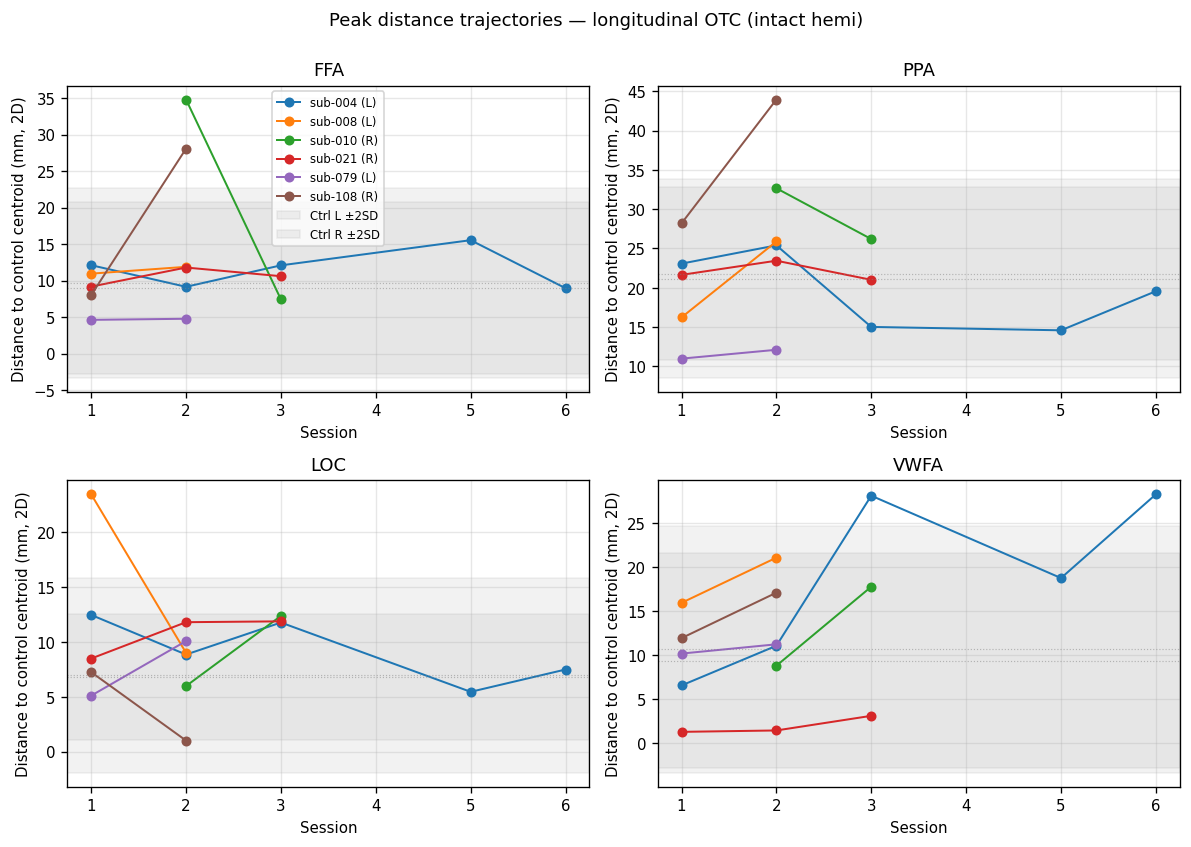

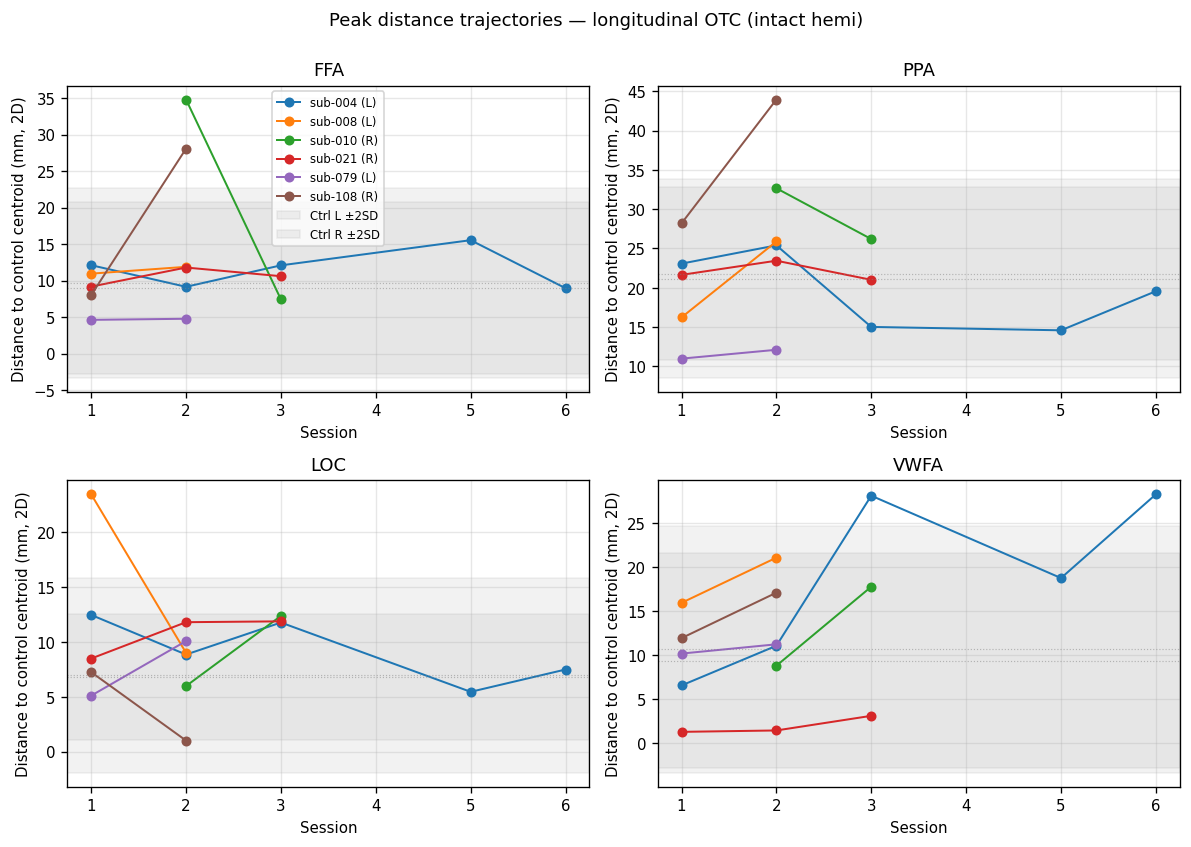

In [6]:
# ── Trajectory plot: all longitudinal OTC × primary parcels in intact hemi ──
def plot_trajectories(metric_df, value_col, ylabel, title, fname,
                      higher_is_better=False):
    """One panel per primary parcel. X = session. Y = metric.
    Control band = mean ± 2 SD across control first sessions, in the
    matched hemi per patient (so each patient line plotted against its
    own intact-hemi reference band).
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
    for ax, parcel in zip(axes.flat, PRIMARY_PARCELS):
        # Plot each patient in their intact hemi
        for sub in long_otc:
            hemi = patient_intact_hemi(sub)
            p = metric_df[(metric_df['subject_id']==sub) &
                          (metric_df['parcel']==parcel) &
                          (metric_df['hemi']==hemi)].sort_values('session')
            if p.empty:
                continue
            label = f'{sub} ({hemi.upper()})'
            ax.plot(p['session'], p[value_col], '-o', label=label,
                    markersize=5, linewidth=1.2)
        # Control band (overlay both hemis as separate bands? or pool?)
        # Use intact-hemi pooled across patients — but patients differ in
        # intact side, so plot both LH and RH control bands lightly.
        for hemi, hatch in (('l', '//'), ('r', '\\\\')):
            ctrl = metric_df[(metric_df['group']=='control') &
                             (metric_df['parcel']==parcel) &
                             (metric_df['hemi']==hemi)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl = ctrl[ctrl['session']==ctrl['fs']][value_col].values
            m, sd, lo, hi = control_ref_band(ctrl)
            if not np.isnan(lo):
                ax.axhspan(lo, hi, alpha=0.10, color='gray',
                           label=f'Ctrl {hemi.upper()} ±2SD' if parcel==PRIMARY_PARCELS[0] else None)
                ax.axhline(m, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        ax.set_title(PARCEL_LABEL[parcel])
        ax.set_xlabel('Session')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
    axes.flat[0].legend(fontsize=7, loc='best')
    fig.suptitle(title, y=1.00)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

plot_trajectories(dist_df, 'distance',
                  'Distance to control centroid (mm, 2D)',
                  'Peak distance trajectories — longitudinal OTC (intact hemi)',
                  'M1_peak_distance_trajectories.png')

## Measure 2: Sum-selectivity (log10 sum_selec_norm)

Liu's selectivity strength metric, log-transformed. Cross-sectional finding: object_LOC LH-intact reduced (Δ = −0.32, p = .0006, q = .012).

**Hypothesis:** post-resection sum-sel is lower than control mean; trajectories show whether reduction persists, recovers, or worsens.

In [7]:
sumsel_rows = []
for _, r in peak_u.iterrows():
    v = r['sum_selec_norm']
    if pd.notna(v) and v > 0 and r['category'] in PRIMARY_PARCELS:
        sumsel_rows.append({
            'subject_id': r['subject_id'], 'session': r['session'],
            'group': r['group'], 'intact_hemi': r.get('intact_hemi', ''),
            'parcel': r['category'], 'hemi': r['hemi'],
            'log10_sumsel': float(np.log10(v)),
        })
sumsel_df = pd.DataFrame(sumsel_rows)
print(f'Sum-sel rows: {len(sumsel_df):,}')

Sum-sel rows: 575


TC pre/post — Sum-selectivity log10 (intact RH)
Parcel              Pre       Post        Δ   Ctrl M    p_pre   p_post
------------------------------------------------------------------------
face_FFA          3.075      3.037   -0.038    2.622    0.340    0.382
house_PPA         3.003      2.912   -0.091    2.770    0.716    0.825
object_LOC        3.052      3.219   +0.167    3.146    0.742    0.795
word_VWFA         2.412      3.156   +0.744    2.066    0.683    0.203


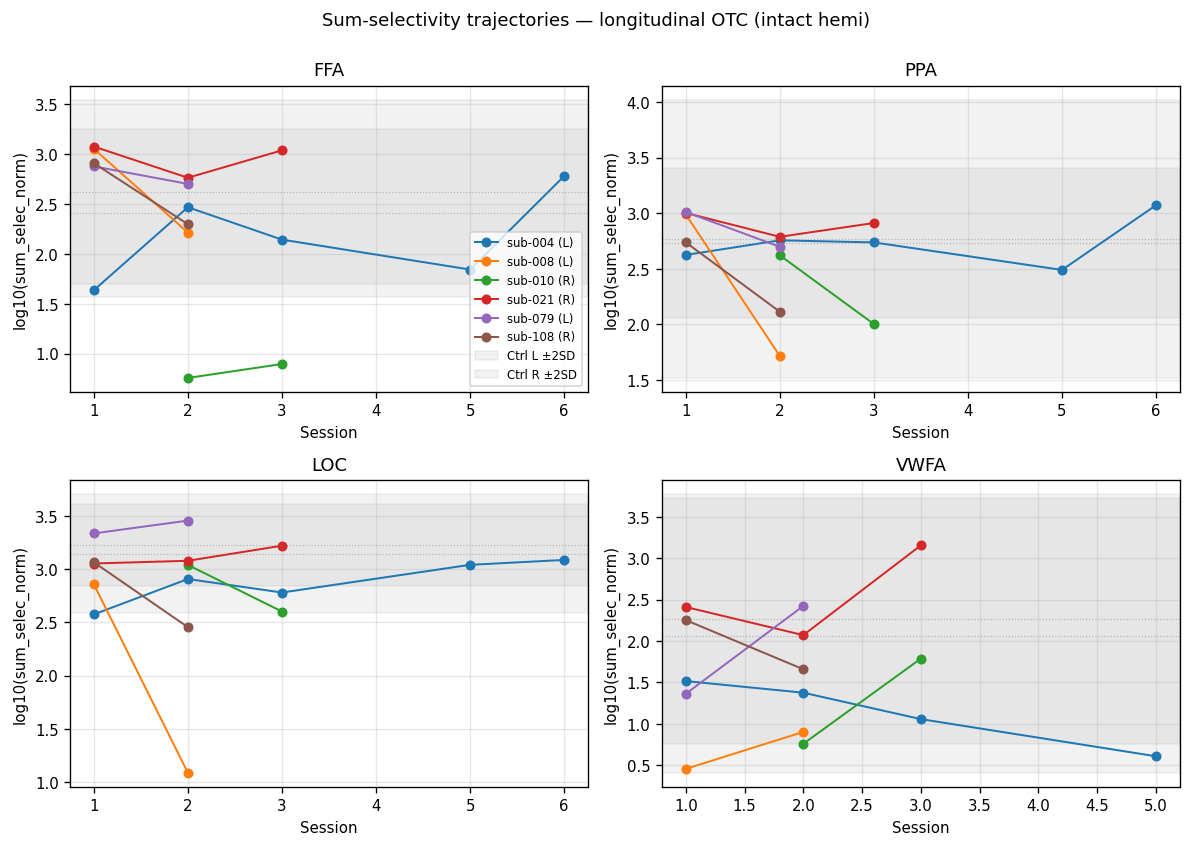

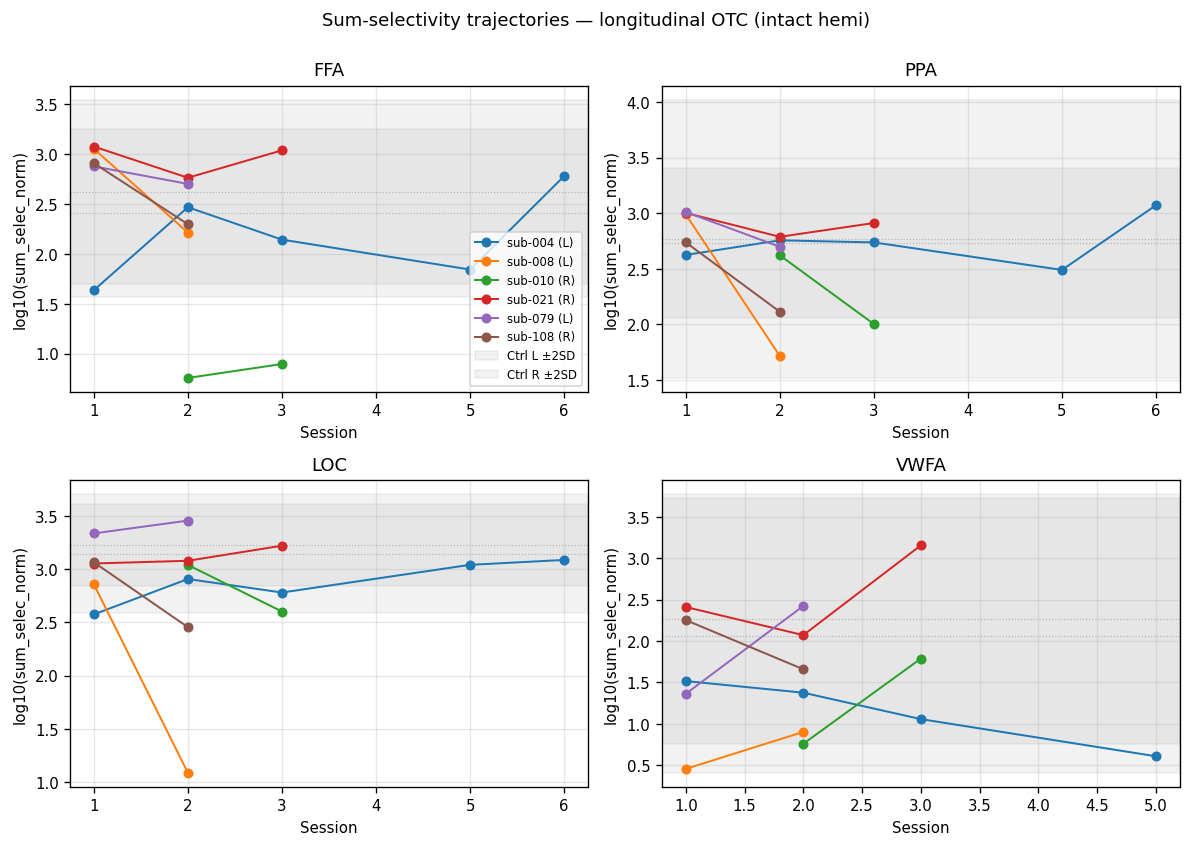

In [8]:
# TC pre/post (intact RH)
if TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('TC pre/post — Sum-selectivity log10 (intact RH)')
    print('=' * 72)
    print(f'{"Parcel":<12} {"Pre":>10} {"Post":>10} {"Δ":>8} '
          f'{"Ctrl M":>8} {"p_pre":>8} {"p_post":>8}')
    print('-' * 72)
    for parcel in PRIMARY_PARCELS:
        tc = sumsel_df[(sumsel_df['subject_id']==TC_SUB) & (sumsel_df['parcel']==parcel) &
                       (sumsel_df['hemi']=='r')]
        pre  = tc[tc['session']==TC_PRE_SES]['log10_sumsel']
        post = tc[tc['session']==TC_POST_SES]['log10_sumsel']
        if pre.empty or post.empty:
            continue
        ctrl = sumsel_df[(sumsel_df['group']=='control') & (sumsel_df['parcel']==parcel) &
                         (sumsel_df['hemi']=='r')]
        ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
        ctrl_v = ctrl[ctrl['session']==ctrl['fs']]['log10_sumsel'].values
        _,_,p_pre,_  = crawford_t(pre.iloc[0],  ctrl_v)
        _,_,p_post,_ = crawford_t(post.iloc[0], ctrl_v)
        print(f'{parcel:<12} {pre.iloc[0]:>10.3f} {post.iloc[0]:>10.3f} '
              f'{post.iloc[0]-pre.iloc[0]:>+8.3f} {np.mean(ctrl_v):>8.3f} '
              f'{p_pre:>8.3f} {p_post:>8.3f}')

plot_trajectories(sumsel_df, 'log10_sumsel',
                  'log10(sum_selec_norm)',
                  'Sum-selectivity trajectories — longitudinal OTC (intact hemi)',
                  'M2_sumsel_trajectories.png')

## Measure 3: Distinctiveness (Liu Fisher-z)

Lower Fisher-z = preferred category response is more distinct from non-preferred. Cross-sectional finding (with caveats): rVWFA RH-intact distinctiveness reduced (Δ = +0.34, raw p = .049, fails BH-FDR).

**Hypothesis:** post-resection distinctiveness drifts toward less distinct (higher Fisher-z) in primary parcels of the intact hemisphere.

Distinctiveness rows: 581

TC pre/post — Distinctiveness (Fisher-z, intact RH)
Parcel              Pre       Post        Δ   Ctrl M    p_pre   p_post
------------------------------------------------------------------------
face_FFA          1.252      1.270   +0.018    0.548    0.070    0.064
house_PPA         0.886      0.640   -0.246    0.495    0.644    0.864
object_LOC        1.569      1.474   -0.094    1.232    0.515    0.638
word_VWFA         0.906      1.148   +0.242    0.365    0.312    0.147


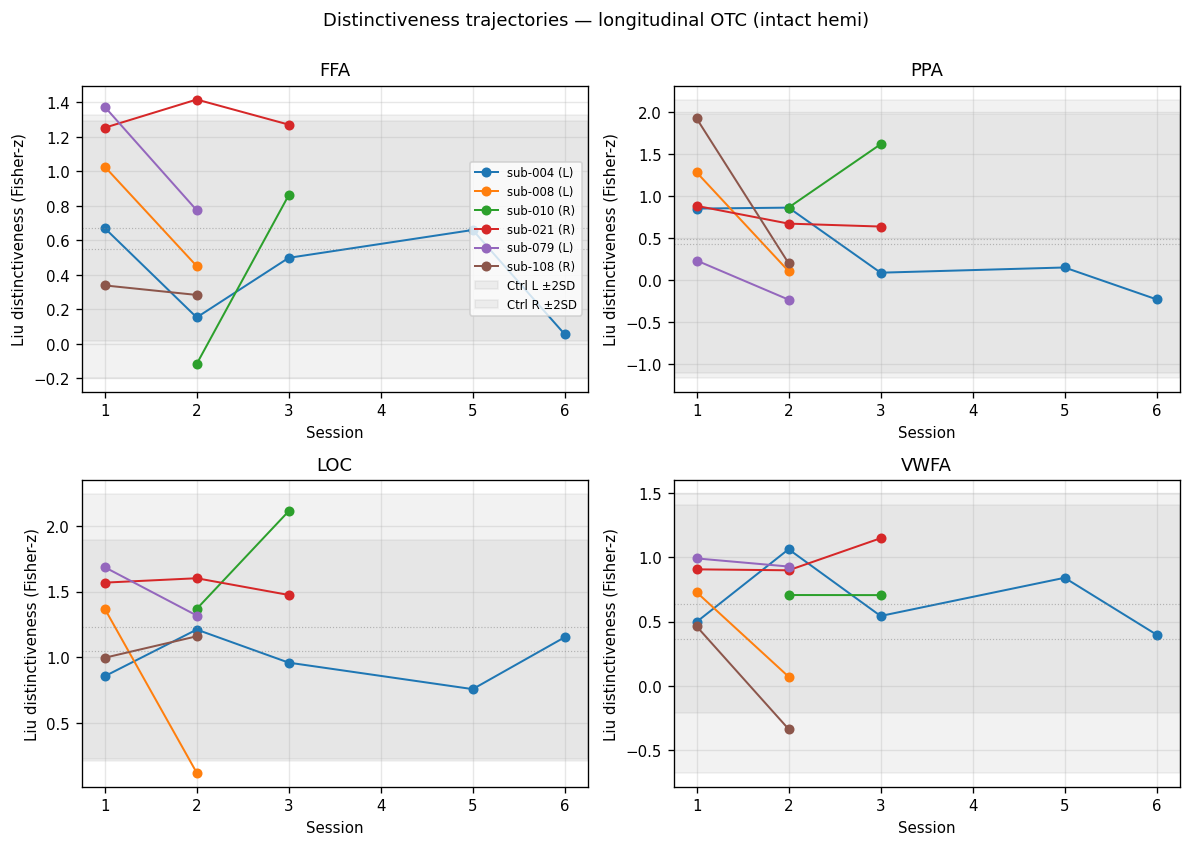

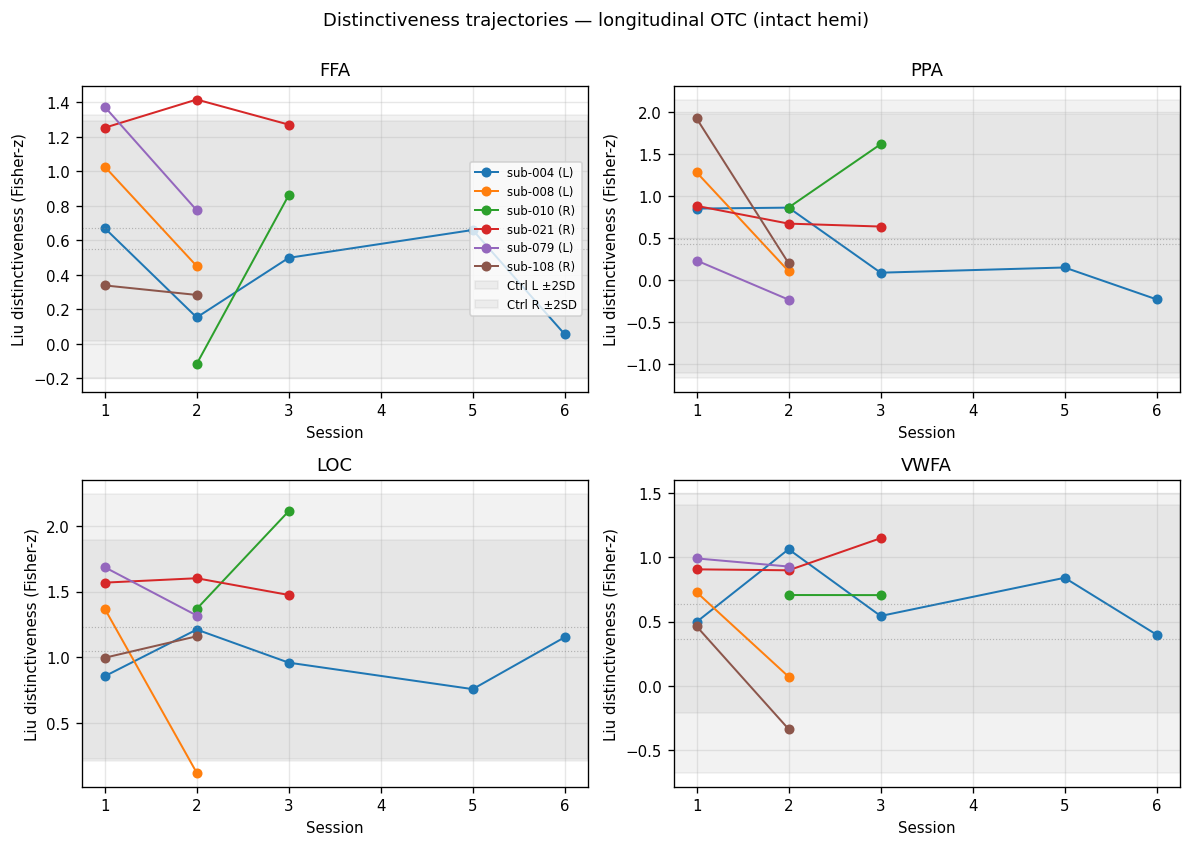

In [9]:
dist_rows = []
for _, r in peak_u.iterrows():
    v = r['liu_distinctiveness']
    if pd.notna(v) and r['category'] in PRIMARY_PARCELS:
        dist_rows.append({
            'subject_id': r['subject_id'], 'session': r['session'],
            'group': r['group'], 'intact_hemi': r.get('intact_hemi', ''),
            'parcel': r['category'], 'hemi': r['hemi'], 'fisher_z': float(v),
        })
distinct_df = pd.DataFrame(dist_rows)
print(f'Distinctiveness rows: {len(distinct_df):,}')

# TC pre/post
if TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('\nTC pre/post — Distinctiveness (Fisher-z, intact RH)')
    print('=' * 72)
    print(f'{"Parcel":<12} {"Pre":>10} {"Post":>10} {"Δ":>8} '
          f'{"Ctrl M":>8} {"p_pre":>8} {"p_post":>8}')
    print('-' * 72)
    for parcel in PRIMARY_PARCELS:
        tc = distinct_df[(distinct_df['subject_id']==TC_SUB) & (distinct_df['parcel']==parcel) &
                         (distinct_df['hemi']=='r')]
        pre  = tc[tc['session']==TC_PRE_SES]['fisher_z']
        post = tc[tc['session']==TC_POST_SES]['fisher_z']
        if pre.empty or post.empty:
            continue
        ctrl = distinct_df[(distinct_df['group']=='control') & (distinct_df['parcel']==parcel) &
                           (distinct_df['hemi']=='r')]
        ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
        ctrl_v = ctrl[ctrl['session']==ctrl['fs']]['fisher_z'].values
        _,_,p_pre,_  = crawford_t(pre.iloc[0],  ctrl_v)
        _,_,p_post,_ = crawford_t(post.iloc[0], ctrl_v)
        print(f'{parcel:<12} {pre.iloc[0]:>10.3f} {post.iloc[0]:>10.3f} '
              f'{post.iloc[0]-pre.iloc[0]:>+8.3f} {np.mean(ctrl_v):>8.3f} '
              f'{p_pre:>8.3f} {p_post:>8.3f}')

plot_trajectories(distinct_df, 'fisher_z',
                  'Liu distinctiveness (Fisher-z)',
                  'Distinctiveness trajectories — longitudinal OTC (intact hemi)',
                  'M3_distinctiveness_trajectories.png')

## Measure 4A: TFCE persistence

Per (sub × ses × cluster), three summary stats extracted from the cluster's own category-vs-others zstat (cope 6/7/8/9):
- `mean_z` — selectivity strength
- `sum_z` — territory loss/gain proxy
- `n_voxels_above` — count at z > 2.326

Clusters: object_L, house_R, word_R, face_L (cross-sectional TFCE survivors, corrp > 0.95).

**Input CSV:** `longitudinal/tfce/tfce_persistence.csv` (from `longitudinal_tfce_trajectories.py`).

In [10]:
PERSIST_CSV = TFCE_LONG_DIR / 'tfce_persistence.csv'

if not PERSIST_CSV.exists():
    print(f'NOT YET AVAILABLE: {PERSIST_CSV}')
    print('Run: python longitudinal_tfce_trajectories.py')
    persist_df = None
else:
    persist_df = pd.read_csv(PERSIST_CSV)
    print(f'Loaded {len(persist_df):,} rows from {PERSIST_CSV.name}')
    print(persist_df.head())

NOT YET AVAILABLE: /user_data/csimmon2/sym_pt/group_results/longitudinal/tfce/tfce_persistence.csv
Run: python longitudinal_tfce_trajectories.py


In [11]:
# ── TFCE persistence trajectories ─────────────────────────────────────
# Three subplots per cluster (mean_z, sum_z, n_voxels), longitudinal patients only.
TFCE_CLUSTERS = ['object_L', 'house_R', 'word_R', 'face_L']

if persist_df is not None:
    for stat in ['mean_z', 'sum_z', 'n_voxels_above']:
        fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
        for ax, cluster in zip(axes.flat, TFCE_CLUSTERS):
            for sub in long_otc:
                p = persist_df[(persist_df['subject_id']==sub) &
                               (persist_df['cluster']==cluster)].sort_values('session')
                if p.empty:
                    continue
                ax.plot(p['session'], p[stat], '-o', label=sub, markersize=5)
            # Control reference band
            ctrl = persist_df[(persist_df['group']=='control') & (persist_df['cluster']==cluster)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl_v = ctrl[ctrl['session']==ctrl['fs']][stat].values
            _, _, lo, hi = control_ref_band(ctrl_v)
            if not np.isnan(lo):
                ax.axhspan(lo, hi, alpha=0.10, color='gray', label='Ctrl ±2SD')
            ax.set_title(cluster)
            ax.set_xlabel('Session')
            ax.set_ylabel(stat)
            ax.grid(alpha=0.3)
        axes.flat[0].legend(fontsize=7, loc='best')
        fig.suptitle(f'TFCE cluster persistence — {stat}', y=1.00)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'M4A_tfce_persistence_{stat}.png', dpi=150, bbox_inches='tight')
        plt.show()

In [12]:
# ── TC pre/post for TFCE persistence ──────────────────────────────────
# TC's intact hemisphere is right → meaningful clusters are house_R and word_R.
if persist_df is not None and TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    print('TC pre/post — TFCE persistence (RH clusters only)')
    print('=' * 80)
    for stat in ['mean_z', 'sum_z', 'n_voxels_above']:
        print(f'\n[{stat}]')
        print(f'{"Cluster":<10} {"Pre":>10} {"Post":>10} {"Δ":>10} '
              f'{"Ctrl M":>10} {"p_pre":>8} {"p_post":>8}')
        print('-' * 80)
        for cluster in ['house_R', 'word_R']:
            tc = persist_df[(persist_df['subject_id']==TC_SUB) & (persist_df['cluster']==cluster)]
            pre  = tc[tc['session']==TC_PRE_SES][stat]
            post = tc[tc['session']==TC_POST_SES][stat]
            if pre.empty or post.empty:
                continue
            ctrl = persist_df[(persist_df['group']=='control') & (persist_df['cluster']==cluster)]
            ctrl = ctrl.merge(first_ses.rename('fs'), on='subject_id')
            ctrl_v = ctrl[ctrl['session']==ctrl['fs']][stat].values
            _,_,p_pre,_  = crawford_t(pre.iloc[0],  ctrl_v)
            _,_,p_post,_ = crawford_t(post.iloc[0], ctrl_v)
            print(f'{cluster:<10} {pre.iloc[0]:>10.3f} {post.iloc[0]:>10.3f} '
                  f'{post.iloc[0]-pre.iloc[0]:>+10.3f} {np.mean(ctrl_v):>10.3f} '
                  f'{p_pre:>8.3f} {p_post:>8.3f}')

## Measure 4B: TFCE preference shifts (Liu McNemar-style)

Per (subject × session-pair × cluster): voxel-wise WTA category at session A vs session B. Voxels enter only if peak z > 2.326 at BOTH sessions. 4×4 transition counts; McNemar χ² tests asymmetry of off-diagonal pairs (e.g., is object→word > word→object within the word_R cluster?).

**Input CSV:** `longitudinal/tfce/tfce_transitions.csv`.

In [13]:
TRANS_CSV = TFCE_LONG_DIR / 'tfce_transitions.csv'

if not TRANS_CSV.exists():
    print(f'NOT YET AVAILABLE: {TRANS_CSV}')
    print('Run: python longitudinal_tfce_trajectories.py')
    trans_df = None
else:
    trans_df = pd.read_csv(TRANS_CSV)
    print(f'Loaded {len(trans_df):,} rows')
    print(trans_df.head())

NOT YET AVAILABLE: /user_data/csimmon2/sym_pt/group_results/longitudinal/tfce/tfce_transitions.csv
Run: python longitudinal_tfce_trajectories.py


In [14]:
# ── McNemar-style asymmetry test per (sub, cluster, session-pair) ─────
CATEGORIES = ['face', 'house', 'object', 'word']

def mcnemar_exact(b, c):
    """Exact binomial McNemar test on counts b and c (off-diagonal).
    Returns (stat, p). Uses two-sided binomial."""
    n = b + c
    if n == 0:
        return np.nan, np.nan
    p = stats.binomtest(min(b, c), n=n, p=0.5).pvalue
    stat = (b - c)**2 / n if n > 0 else np.nan
    return stat, p

def transition_matrix(trans_df, sub, cluster, ses_a, ses_b):
    """Return 4x4 matrix [from_cat × to_cat] of counts."""
    sub_df = trans_df[(trans_df['subject_id']==sub) & (trans_df['cluster']==cluster) &
                      (trans_df['ses_a']==ses_a)  & (trans_df['ses_b']==ses_b)]
    M = np.zeros((4, 4), dtype=int)
    for _, r in sub_df.iterrows():
        i = CATEGORIES.index(r['from_cat'])
        j = CATEGORIES.index(r['to_cat'])
        M[i, j] = r['count']
    return M

def mcnemar_summary(M, label='M'):
    print(f'\n{label}: total voxels = {M.sum()}')
    print(f'  Stable: {np.diag(M).sum()} ({100*np.diag(M).sum()/max(M.sum(),1):.1f}%)')
    print(f'  Asymmetric pair tests (off-diagonal):')
    print(f'  {"from→to":<18} {"b (a→b)":>8} {"c (b→a)":>8} {"χ²":>8} {"p":>8}')
    for i in range(4):
        for j in range(i+1, 4):
            b = M[i, j]; c = M[j, i]
            if b + c < 5:
                continue
            stat, p = mcnemar_exact(b, c)
            sig = '*' if p < .05 else ''
            print(f'  {CATEGORIES[i]:>6}→{CATEGORIES[j]:<10} {b:>8d} {c:>8d} '
                  f'{stat:>8.2f} {p:>8.3f} {sig}')

In [15]:
# ── TC pre/post transitions, intact-hemi clusters ─────────────────────
if trans_df is not None and TC_PRE_SES in tc_sessions and TC_POST_SES in tc_sessions:
    for cluster in ['house_R', 'word_R']:
        print(f'\n{"="*72}')
        print(f'TC {cluster}: ses-{TC_PRE_SES:02d} → ses-{TC_POST_SES:02d}')
        print(f'{"="*72}')
        M = transition_matrix(trans_df, TC_SUB, cluster, TC_PRE_SES, TC_POST_SES)
        print('Transition matrix (rows=pre, cols=post):')
        print(pd.DataFrame(M, index=CATEGORIES, columns=CATEGORIES))
        mcnemar_summary(M, f'TC/{cluster}')

In [16]:
# ── Transition heatmaps for all longitudinal patients ─────────────────
# One figure per cluster, subplots = patients × earliest-vs-latest session pair.
if trans_df is not None:
    for cluster in TFCE_CLUSTERS:
        rel_subs = []
        for sub in long_otc:
            sub_p = trans_df[(trans_df['subject_id']==sub) & (trans_df['cluster']==cluster)]
            if sub_p.empty:
                continue
            # Use earliest available ses_a and latest ses_b for that subject
            ses_a = sub_p['ses_a'].min()
            ses_b = sub_p[sub_p['ses_a']==ses_a]['ses_b'].max()
            rel_subs.append((sub, ses_a, ses_b))
        if not rel_subs:
            continue
        n = len(rel_subs)
        fig, axes = plt.subplots(1, n, figsize=(3*n, 3.2), squeeze=False)
        for ax, (sub, sa, sb) in zip(axes[0], rel_subs):
            M = transition_matrix(trans_df, sub, cluster, sa, sb)
            im = ax.imshow(M, cmap='Blues')
            ax.set_xticks(range(4)); ax.set_yticks(range(4))
            ax.set_xticklabels(CATEGORIES, rotation=45)
            ax.set_yticklabels(CATEGORIES)
            for i in range(4):
                for j in range(4):
                    ax.text(j, i, str(M[i,j]), ha='center', va='center',
                            color='white' if M[i,j]>M.max()/2 else 'black', fontsize=8)
            ax.set_title(f'{sub}\nses-{sa:02d}→ses-{sb:02d}', fontsize=8)
            ax.set_xlabel('to')
            ax.set_ylabel('from')
        fig.suptitle(f'{cluster}: WTA preference shifts', y=1.02)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'M4B_transitions_{cluster}.png', dpi=150, bbox_inches='tight')
        plt.show()

---

## Notes for write-up

- **Cross-sectional vs longitudinal framing:** CS = state at one timepoint; longitudinal = trajectory over time. Headline question for this section: "Do CS findings persist within-subject over time, and does TC pre/post show change in the predicted direction?"
- **n=1 for TC pre/post:** report directional shifts + Crawford-H p-values; flag as case study, not group inference.
- **Other 5 patients (post-only):** test for stability, not pre-post change.
- **TC pre-surgical RH atypical (per Liu 2025):** baseline already contains pathological reorganization; soften causal claims.
- **Sub-108 ses-02:** needs `13_register_zstats_mni.py` for that single session before it enters analyses.